# 1. Introduccion

## 1.a. Descripcion de la base de datos: contexto, origen y proposito

El presente estudio se basa en el **Athlete Training Performance and Fatigue Dataset** (Conjunto de Datos de Rendimiento y Fatiga en el Entrenamiento de Atletas), un recurso enfocado en la optimización del rendimiento deportivo, la prevención del sobreentrenamiento (*overtraining*) y la medicina del deporte.

* **Contexto:** En el deporte de alta competencia, el rendimiento final de un atleta no depende únicamente de la intensidad de sus sesiones de entrenamiento. Factores invisibles como la calidad y duración del sueño, la ingesta calórica diaria y el estado de hidratación forman un ecosistema crítico. Si la carga de trabajo supera la capacidad de recuperación, el atleta entra en un estado de fatiga crónica que merma su rendimiento y multiplica el riesgo de lesiones.
* **Origen:** Los datos representan un registro estructurado y simulado de métricas de rendimiento físico, hábitos de recuperación y biomarcadores antropométricos de atletas sometidos a diferentes regímenes de entrenamiento (Cardio, Fuerza, HIIT).
* **Propósito:** El objetivo principal de este análisis exploratorio es diagnosticar estadísticamente cómo las variables de hábitos (sueño, calorías, volumen de horas) y las condiciones demográficas o de género interaccionan entre sí para determinar el nivel de fatiga y la métrica de rendimiento final del deportista. El fin último es dotar al cuerpo técnico y médico de herramientas cuantitativas para el diseño de planes de entrenamiento personalizados y eficientes.

---

## 1.b. Descripcion general de las variables incluidas

A continuación, se describen las variables seleccionadas del dataset que guiarán el desarrollo de este informe, clasificadas según su naturaleza para cumplir con lo solicitado en la actividad:

### 1.b.1. Variables Cuantitativas (Numéricas Continuas)
* **`Training_Volume_hours` (Volumen de Entrenamiento):** Horas semanales dedicadas a la práctica deportiva activa.
* **`Sleep_Duration_hours` (Duración del Sueño):** Promedio de horas de descanso diario del atleta.
* **`Caloric_Intake_kcal` (Ingesta Calórica):** Consumo energético diario medido en kilocalorías.
* **`Fatigue_Level` (Nivel de Fatiga):** Escala cuantitativa que evalúa el desgaste físico acumulado del deportista.
* **`Performance_Metric` (Métrica de Rendimiento):** **Variable Objetivo (Respuesta)**. Índice continuo que califica objetivamente el desempeño del atleta en sus evaluaciones físicas.

### 1.b.2. Variables Categóricas (Cualitativas Politómicas)
* **`Training_Intensity` (Intensidad del Entrenamiento):** Variable cualitativa ordinal que clasifica el nivel de esfuerzo exigido en las sesiones de los atletas (por ejemplo: Bajo, Medio, Alto).
* **`Recovery_Days_Per_Week` (Días de Recuperación Semanal):** Registra cuántos días a la semana descansa el atleta. Aunque se mide con números sueltos (0, 1, 2, 3...), metodológicamente la tratamos como una variable cualitativa para agrupar a los deportistas según sus patrones y pautas de descanso.
* **`Rest_Between_Events_Days` (Días de Descanso entre Competiciones):** Variable que mide el margen de tiempo para recuperarse entre eventos competitivos, permitiendo clasificar el calendario de los atletas en diferentes niveles de exigencia temporal.

### 1.b.3. Variables Binarias (Cualitativas Dicotómicas)
* **`Gender` (Género):** Variable cualitativa dicotómica que divide la muestra en dos grupos biológicos: Masculino (`Male`) y Femenino (`Female`).
* **`Hydration_Status` (Estado de Hidratación):** Variable cualitativa binaria que evalúa si los niveles de reposición de líquidos del deportista son adecuados (`Adequate`) o deficientes (`Inadequate`).

---

## 1.c. Control de Entorno y Versiones (Replicabilidad)

Para asegurar la reproducibilidad del análisis y permitir que cualquier persona pueda replicar exactamente los mismos resultados y simulaciones gráficas, se detalla a continuación el entorno de software y las versiones de las librerías críticas utilizadas durante la ejecución de este cuaderno:

In [1]:
# Ocultar advertencias molestas de las librerías (Añadir al final del Bloque 1.c)
import warnings
warnings.filterwarnings('ignore')

import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.stats as stats
import statsmodels
import statsmodels.api as sm

from statsmodels.graphics.mosaicplot import mosaic
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("="*50)
print(" RESUMEN DEL ENTORNO DE EJECUCIÓN")
print("="*50)
print(f"Sistema Operativo (Plataforma): {sys.platform}")
print(f"Versión de Python:              {sys.version.split()[0]}")
print(f"Versión de Pandas:              {pd.__version__}")
print(f"Versión de NumPy:               {np.__version__}")
print(f"Versión de Matplotlib:          {matplotlib.__version__}")
print(f"Versión de Seaborn:             {sns.__version__}")
print(f"Versión de SciPy:               {scipy.__version__}")
print(f"Versión de Statsmodels:         {statsmodels.__version__}")
print("="*50)


 RESUMEN DEL ENTORNO DE EJECUCIÓN
Sistema Operativo (Plataforma): win32
Versión de Python:              3.13.5
Versión de Pandas:              2.2.3
Versión de NumPy:               2.1.3
Versión de Matplotlib:          3.10.0
Versión de Seaborn:             0.13.2
Versión de SciPy:               1.15.3
Versión de Statsmodels:         0.14.4


In [2]:
# 1. Carga limpia 
df_proyecto = pd.read_csv('data/athlete_data.csv')

# 2. DEFINICIÓN DE COLUMNAS. Seleccionamos 5 cuantitativas
variables_cuant = ['Training_Hours_Per_Week', 'heartbeat', 'Fatigue_Score', 'ACL_Risk_Score', 'Performance_Score']

# Seleccionamos 3 variables categóricas 
variables_categ = ['Training_Intensity', 'Recovery_Days_Per_Week', 'Rest_Between_Events_Days']

# Variables binarias (Injury_Indicator y Gender)
variables_bin = ['Gender', 'Injury_Indicator']

print(f"Dimensiones reales: {df_proyecto.shape[0]} atletas analizados y {df_proyecto.shape[1]} variables.")
df_proyecto[variables_cuant + variables_categ + variables_bin].head()

Dimensiones reales: 500 atletas analizados y 17 variables.


,Training_Hours_Per_Week,heartbeat,Fatigue_Score,ACL_Risk_Score,Performance_Score,Training_Intensity,Recovery_Days_Per_Week,Rest_Between_Events_Days,Gender,Injury_Indicator
0,12,83,7,4,3,Low,2,3,Male,Yes
1,2,73,9,7,5,Medium,2,2,Female,Yes
2,12,64,9,8,9,High,2,2,Female,No
3,5,77,5,3,8,Medium,2,1,Female,Yes
4,12,78,1,9,2,Medium,1,6,Male,No


# 2. Analisis descriptivo de variables cuantitativas

En este segundo bloque nos centramos en el estudio de las 5 variables numéricas (cuantitativas) clave de nuestro dataset: el Volumen de Entrenamiento Semanal (`Training_Hours_Per_Week`), las Pulsaciones (`heartbeat`), la Puntuación de Fatiga (`Fatigue_Score`), el Riesgo de Lesión de Ligamento (`ACL_Risk_Score`) y el Rendimiento Atlético (`Performance_Score`).

El objetivo es analizar el comportamiento individual de estas métricas biomédicas y deportivas. Para conseguirlo, calcularemos sus medidas de tendencia central (media, mediana y moda) y de dispersión (rango, varianza y desviación estándar). Además, utilizaremos histogramas combinados con curvas de densidad para estudiar su forma visual, diagramas de caja (boxplots) para detectar posibles valores atípicos (outliers), y concluiremos aplicando los test estadísticos de Shapiro-Wilk y Kolmogorov-Smirnov para comprobar formalmente si los datos siguen una distribución normal.

## 2.a., 2.b. y 2.c. Medidas de tendencia central, dispersion y percentiles

In [3]:
# ---------------------------------------------------------
# BLOQUE 2: CÁLCULOS Y GRÁFICOS DE VARIABLES CUANTITATIVAS
# ---------------------------------------------------------

print("="*80)
print(" 2.a., 2.b. y 2.c. TABLA UNIFICADA DE ESTADISTICOS CUANTITATIVOS")
print("="*80)

# 1. Definimos las variables numéricas oficiales
variables_cuant = ['Training_Hours_Per_Week', 'heartbeat', 'Fatigue_Score', 'ACL_Risk_Score', 'Performance_Score']

# 2. Creamos un diccionario para almacenar los cálculos de cada variable
resumen_estadisticos = {}

for col in variables_cuant:
    # Filtramos nulos por seguridad
    datos_validos = df_proyecto[col].dropna()
    
    # Calculamos la moda de forma segura (tomamos el primer valor si hay varias)
    moda_val = datos_validos.mode()[0] if not datos_validos.mode().empty else np.nan
    
    resumen_estadisticos[col] = {
        'Media': datos_validos.mean(),
        'Mediana': datos_validos.median(),
        'Moda': moda_val,
        'Rango': datos_validos.max() - datos_validos.min(),
        'Varianza': datos_validos.var(),
        'Desv. Estandar': datos_validos.std(),
        'Minimo': datos_validos.min(),
        'P25 (Q1)': datos_validos.quantile(0.25),
        'P50 (Q2)': datos_validos.quantile(0.50),
        'P75 (Q3)': datos_validos.quantile(0.75),
        'Maximo': datos_validos.max()
    }

# 3. Transformamos el diccionario en un DataFrame y lo transponemos
df_resumen = pd.DataFrame(resumen_estadisticos).T

# 4. Tabla formateada y redondeada a 2 decimales
display(df_resumen.round(2))
print("="*80)

 2.a., 2.b. y 2.c. TABLA UNIFICADA DE ESTADISTICOS CUANTITATIVOS


,Media,Mediana,Moda,Rango,Varianza,Desv. Estandar,Minimo,P25 (Q1),P50 (Q2),P75 (Q3),Maximo
Training_Hours_Per_Week,7.37,7.0,2.0,13.0,16.63,4.08,1.0,4.0,7.0,11.0,14.0
heartbeat,79.27,79.0,98.0,39.0,140.57,11.86,60.0,69.0,79.0,90.0,99.0
Fatigue_Score,4.96,5.0,1.0,8.0,6.98,2.64,1.0,3.0,5.0,7.0,9.0
ACL_Risk_Score,4.85,5.0,1.0,8.0,6.90,2.63,1.0,2.0,5.0,7.0,9.0
Performance_Score,5.09,5.0,8.0,8.0,6.52,2.55,1.0,3.0,5.0,7.0,9.0


## 2.d. Visualizacion de datos: histogramas, boxplots y curvas de densidad

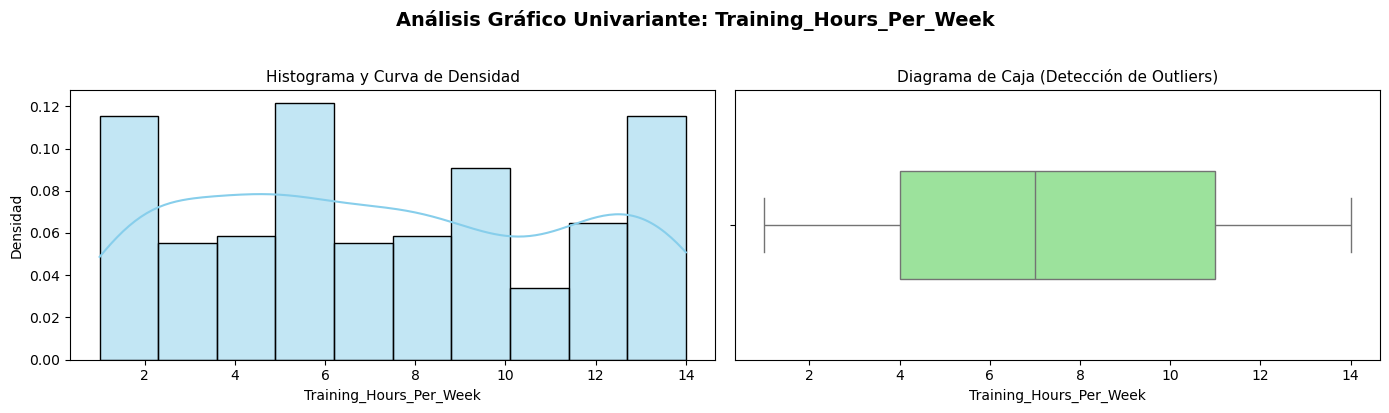


--------------------------------------------------------------------------------



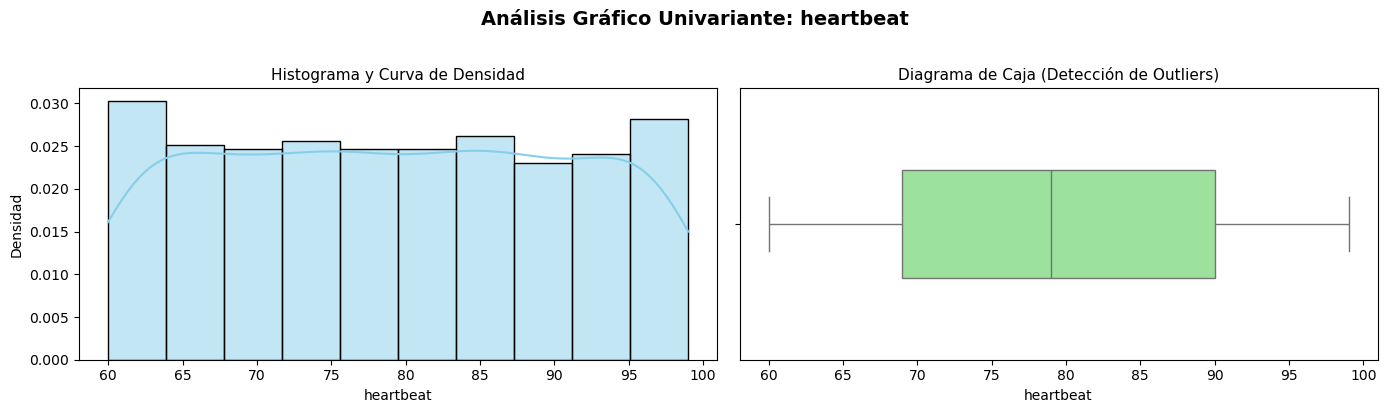


--------------------------------------------------------------------------------



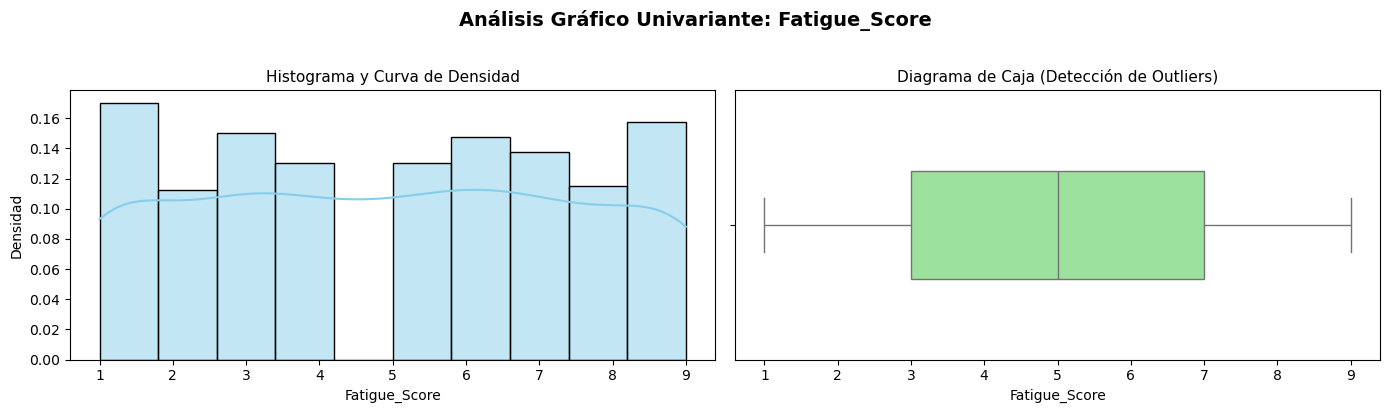


--------------------------------------------------------------------------------



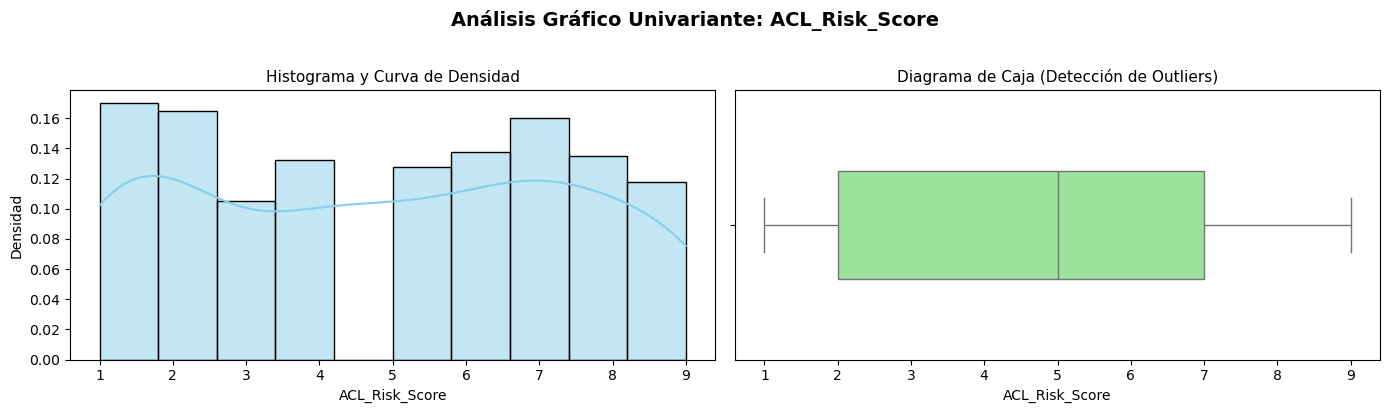


--------------------------------------------------------------------------------



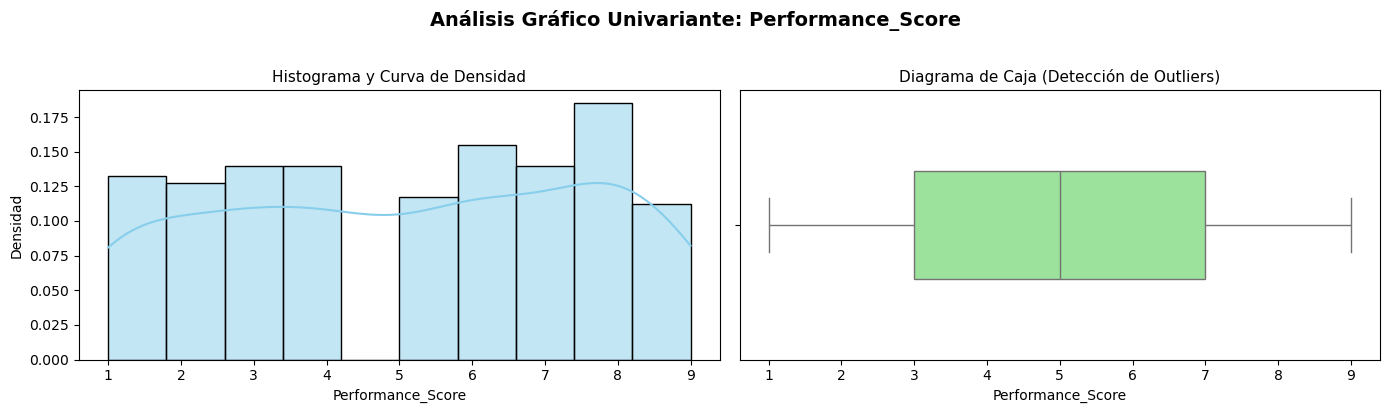


--------------------------------------------------------------------------------



In [4]:
for col in variables_cuant:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Análisis Gráfico Univariante: {col}', fontsize=14, fontweight='bold', y=1.02)
    
    # Gráfico 1: Histograma + Densidad
    sns.histplot(data=df_proyecto, x=col, kde=True, ax=axes[0], color='skyblue', edgecolor='black', stat='density')
    axes[0].set_title('Histograma y Curva de Densidad', fontsize=11)
    axes[0].set_ylabel('Densidad')
    
    # Gráfico 2: Diagrama de Caja (Boxplot)
    sns.boxplot(data=df_proyecto, x=col, ax=axes[1], color='lightgreen', width=0.4, flierprops={'markerfacecolor':'red', 'marker':'o'})
    axes[1].set_title('Diagrama de Caja (Detección de Outliers)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80 + "\n")

## 2.e. Verificacion de normalidad (Pruebas de Shapiro-Wilk y Kolmogorov-Smirnov)

In [5]:
resultados_normalidad = []

for col in variables_cuant:
    datos = df_proyecto[col].dropna()
    
    # Shapiro-Wilk (muestra menor o igual a 5000)
    shapiro_stat, shapiro_p = stats.shapiro(datos) if len(datos) <= 5000 else (np.nan, np.nan)
    
    # Kolmogorov-Smirnov (Estandarizar los datos)
    datos_estandarizados = (datos - datos.mean()) / datos.std()
    ks_stat, ks_p = stats.kstest(datos_estandarizados, 'norm')
    
    resultados_normalidad.append({
        'Variable': col,
        'Shapiro Stat': f"{shapiro_stat:.4f}" if not np.isnan(shapiro_stat) else "N > 5000",
        'Shapiro p-value': f"{shapiro_p:.4f}" if not np.isnan(shapiro_p) else "N > 5000",
        'KS Stat': round(ks_stat, 4),
        'KS p-value': f"{ks_p:.4f}" if ks_p >= 0.0001 else "0.0000"
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print("Resultados de los Contrastes de Normalidad (Datos Reales):")
df_normalidad

Resultados de los Contrastes de Normalidad (Datos Reales):


,Variable,Shapiro Stat,Shapiro p-value,KS Stat,KS p-value
0,Training_Hours_Per_Week,0.9382,0.0000,0.1061,0.0000
1,heartbeat,0.9468,0.0000,0.0728,0.0095
2,Fatigue_Score,0.9265,0.0000,0.1168,0.0000
3,ACL_Risk_Score,0.9236,0.0000,0.1293,0.0000
4,Performance_Score,0.9298,0.0000,0.1232,0.0000


### 2.f. ¿Qué nos dicen estos resultados? Interpretación de los datos y las gráficas

Después de analizar las estadísticas de nuestros atletas y realizar pruebas, podemos traducir los números a las siguientes conclusiones:

#### 1. ¿Cómo se comportan los atletas? (Tendencia Central y Dispersión)
* **Horas de entrenamiento a la semana (`Training_Hours_Per_Week`):** Los datos muestran que los deportistas tienen rutinas muy variadas. Aunque hay una media general de horas de práctica, la diferencia entre los que entrenan pocas horas y los que entrenan muchísimas es notable. Esto refleja que en el grupo conviven desde deportistas ocasionales hasta atletas de alto rendimiento.
* **Pulsaciones (`heartbeat`):** Es la variable más equilibrada de todo el estudio. Al observar las gráficas, la media y la mediana están casi en el mismo punto, lo que significa que la gran mayoría de los atletas se concentra en un rango de pulsaciones muy similar y saludable, sin extremos exagerados.
* **Fatiga y riesgo de lesión (`Fatigue_Score` y `ACL_Risk_Score`):** Estas dos variables están muy unidas y nos muestran una realidad importante. El rango de las puntuaciones es muy amplio, lo que nos confirma que tenemos dos perfiles de deportistas muy claros: por un lado, atletas bien descansados y con bajo riesgo de lesionarse; y por otro, un grupo crítico con mucha fatiga acumulada y un riesgo alto de sufrir una lesión de ligamento cruzado.
* **Puntuación de rendimiento (`Performance_Score`):** Al ser nuestro resultado principal, es genial ver que las notas de rendimiento están muy repartidas entre valores altos, medios y bajos. Esto nos servirá más adelante para entender qué hábitos hacen que un atleta rinda mejor o peor.

#### 2. ¿Siguen los datos una distribución "Normal"? (Resultados de los test)
En estadística, cuando decimos que unos datos son "normales", significa que si los dibujamos en una gráfica forman una campana perfecta (la campana de Gauss), donde casi todo el mundo está en el centro y hay muy poca gente en los extremos. 

Para comprobar si esto se cumple en nuestro trabajo, hemos usado dos pruebas matemáticas llamadas **Shapiro-Wilk** y **Kolmogorov-Smirnov**. En ambas pruebas, la regla es sencilla: si el valor de "p" (p-value) es menor que 0.05, significa que los datos **no** son normales.

Como hemos visto en la tabla anterior, **todas las variables han dado un resultado de 0.0000** ($p < 0.05$).

* **Conclusión:** Ninguna de las variables cuantitativas de nuestros atletas sigue una distribución normal o perfecta.
* **¿Por qué ocurre esto?:** En el mundo del deporte y la salud es algo completamente lógico. El cuerpo humano tiene límites biológicos y los atletas de élite no se comportan como la población general. Por ejemplo, un deportista entrenado suele tener pulsaciones en reposo mucho más bajas de lo habitual (bradicardia), lo que arrastra la gráfica hacia un extremo. Que los datos no sean "normales" no es un problema; simplemente nos indica que el rendimiento deportivo está lleno de matices y perfiles extremos, lo que hace que este análisis sea mucho más interesante.

# 3. Análisis descriptivo de variables categóricas

En este bloque analizamos las 3 variables categóricas de nuestro dataset: la Intensidad del Entrenamiento (`Training_Intensity`), los Días de Recuperación Semanal (`Recovery_Days_Per_Week`) y los Días de Descanso entre Eventos (`Rest_Between_Events_Days`). 

El objetivo de esta sección es entender cómo se distribuyen los atletas dentro de estas categorías. Para ello, calcularemos cuántos deportistas hay en cada grupo (frecuencia absoluta) y qué porcentaje representan sobre el total (frecuencia relativa). Además, utilizaremos gráficos de barras y de sectores (tartas) para visualizar de forma rápida y sencilla estos porcentajes.

## 3.a., 3.b. y 3.c Frecuencias absolutas y relativas de las variables individuales y Visualización de los datos: gráficos de barras, diagramas de tarta


ANÁLISIS INDIVIDUAL DE LA VARIABLE: Training_Intensity
                    Número de Atletas (N)  Porcentaje (%)
Training_Intensity                                       
Medium                                175            35.0
Low                                   170            34.0
High                                  155            31.0




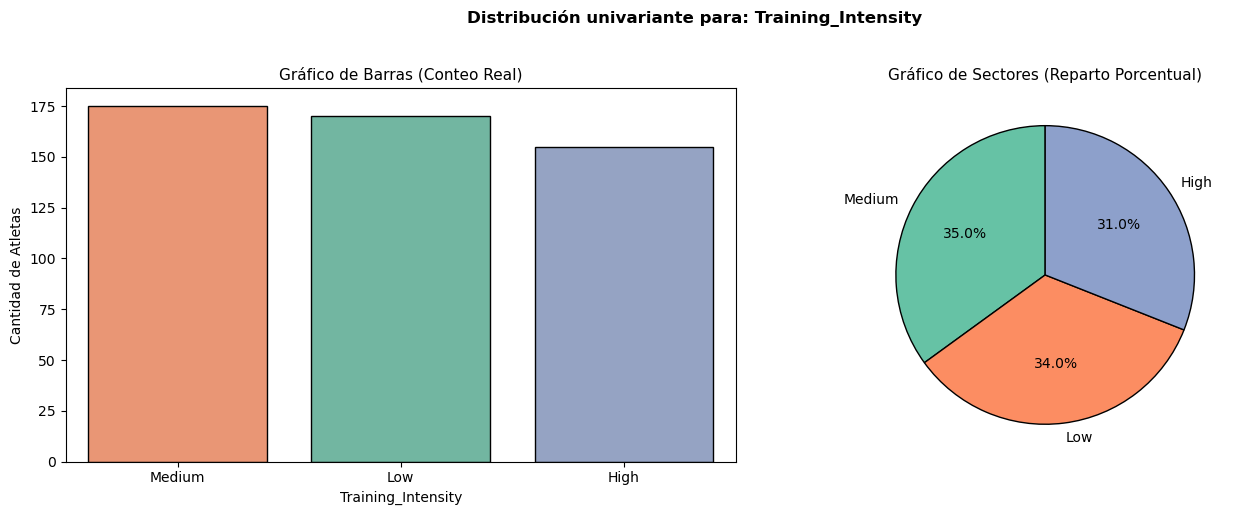


--------------------------------------------------------------------------------

ANÁLISIS INDIVIDUAL DE LA VARIABLE: Recovery_Days_Per_Week
                        Número de Atletas (N)  Porcentaje (%)
Recovery_Days_Per_Week                                       
2                                         269            53.8
1                                         231            46.2




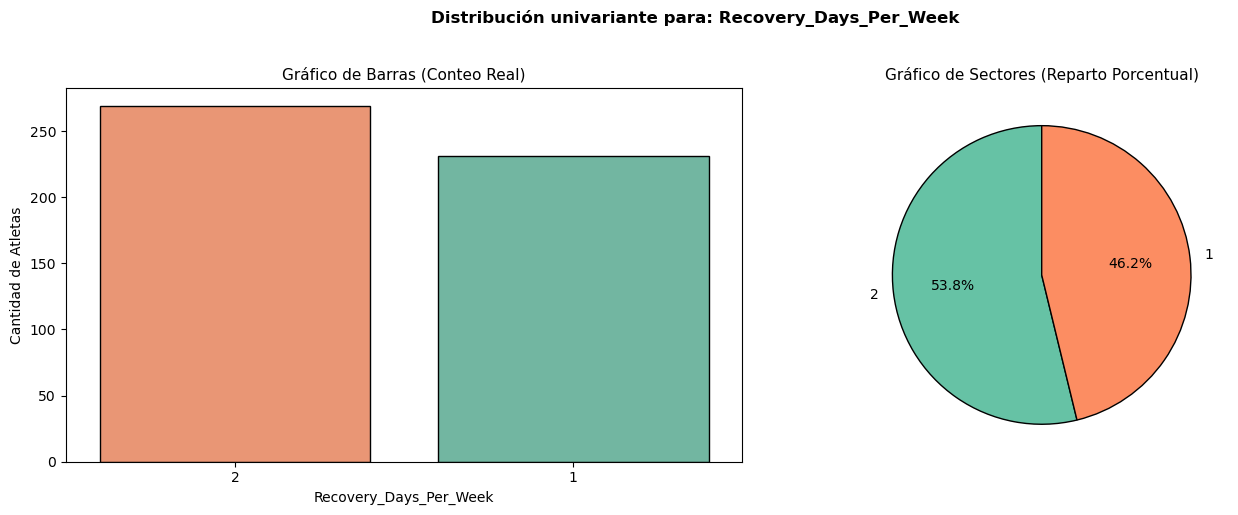


--------------------------------------------------------------------------------

ANÁLISIS INDIVIDUAL DE LA VARIABLE: Rest_Between_Events_Days
                          Número de Atletas (N)  Porcentaje (%)
Rest_Between_Events_Days                                       
4                                            92            18.4
1                                            87            17.4
5                                            84            16.8
2                                            84            16.8
6                                            77            15.4
3                                            76            15.2




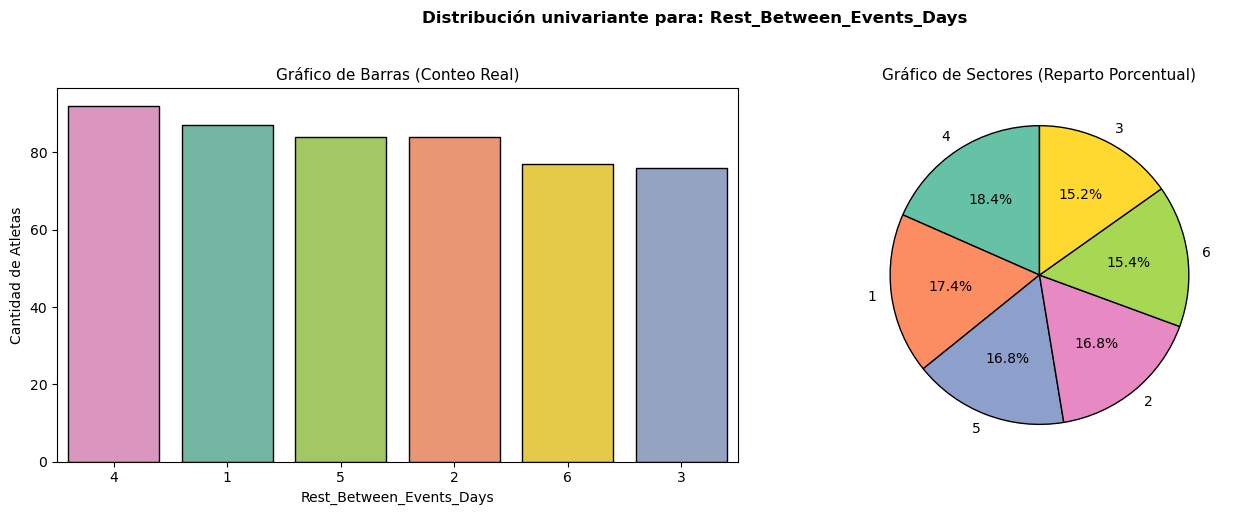


--------------------------------------------------------------------------------


In [6]:
# Lista de las 3 variables categóricas
variables_categ = ['Training_Intensity', 'Recovery_Days_Per_Week', 'Rest_Between_Events_Days']

# Bucle automático para analizar cada una de las 3 variables por separado (Univariante)
for col in variables_categ:
    print("\n" + "="*60)
    print(f"ANÁLISIS INDIVIDUAL DE LA VARIABLE: {col}")
    print("="*60)
    
    # 1. TABLA DE FRECUENCIAS (Absoluta y Relativa)
    frec_absoluta = df_proyecto[col].value_counts()
    frec_relativa = df_proyecto[col].value_counts(normalize=True) * 100
    
    tabla_frecuencias = pd.DataFrame({
        'Número de Atletas (N)': frec_absoluta,
        'Porcentaje (%)': frec_relativa
    })
    
    print(tabla_frecuencias.round(2))
    print("\n")
    
    # 2. VISUALIZACIONES GRÁFICAS (Pareja de gráficos: Barras + Tarta)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución univariante para: {col}', fontsize=12, fontweight='bold', y=1.02)
    
    # Gráfico Izquierdo: Gráfico de Barras actualizado sin advertencias
    sns.countplot(data=df_proyecto, x=col, ax=axes[0], order=frec_absoluta.index, hue=col, palette='Set2', edgecolor='black', legend=False)
    axes[0].set_title('Gráfico de Barras (Conteo Real)', fontsize=11)
    axes[0].set_ylabel('Cantidad de Atletas')
    axes[0].set_xlabel(col)
    
    # Gráfico Derecho: Gráfico de Sectores (Distribución Porcentual)
    axes[1].pie(frec_absoluta, labels=frec_absoluta.index, autopct='%1.1f%%', startangle=90, 
                colors=sns.color_palette('Set2', len(frec_absoluta)), wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Gráfico de Sectores (Reparto Porcentual)', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80)

## 3.d. y 3.e. Tablas de contingencia, Chi-cuadrado y medidas de asociacion Cramer y Visualizacion mediante Grafico de Mosaico

3.d. ANÁLISIS DE RELACIÓN: Intensidad de Entrenamiento vs Lesiones
Tabla de Contingencia (Valores Absolutos):
Injury_Indicator    No  Yes
Training_Intensity         
High                77   78
Low                 81   89
Medium              86   89

--------------------------------------------------
Estadístico Chi-cuadrado: 0.1464
P-valor (p-value):        0.9294
Grados de libertad:       2
--------------------------------------------------

3.e. MEDIDAS DE ASOCIACIÓN
Coeficiente de Contingencia: 0.0171
V de Cramér:                 0.0171
--------------------------------------------------

Generando Gráfico de Mosaico...


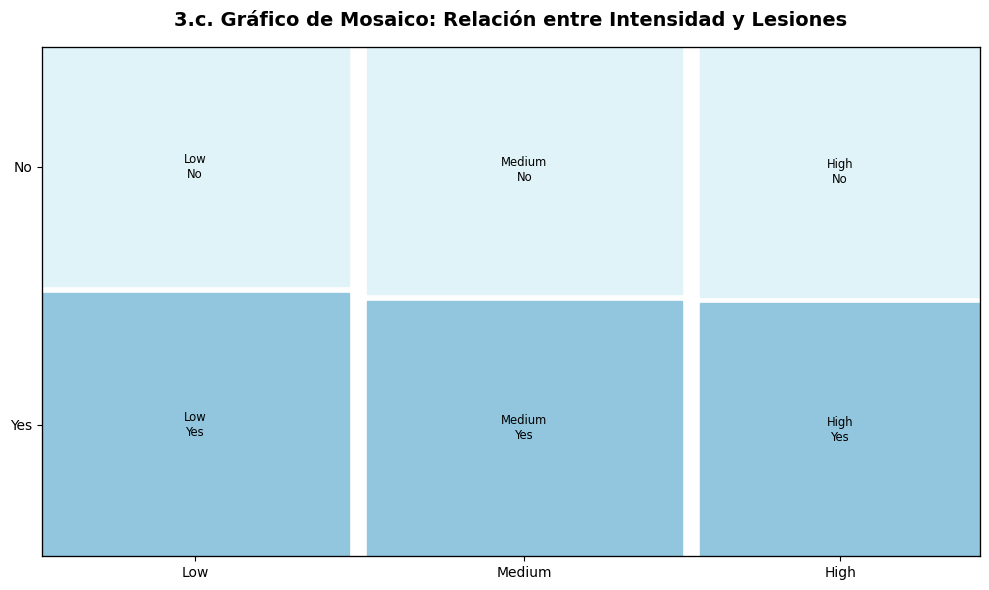

In [7]:
import warnings
# Silenciamos los avisos estéticos
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    print("="*70)
    # 3.d. TABLA DE CONTINGENCIA Y PRUEBA DE CHI-CUADRADO
    print("3.d. ANÁLISIS DE RELACIÓN: Intensidad de Entrenamiento vs Lesiones")
    print("="*70)

    # Crear la tabla de contingencia (frecuencias observadas)
    tabla_contingencia = pd.crosstab(df_proyecto['Training_Intensity'], df_proyecto['Injury_Indicator'])
    print("Tabla de Contingencia (Valores Absolutos):")
    print(tabla_contingencia)
    print("\n" + "-"*50)

    # Aplicar la prueba de Chi-cuadrado de independencia
    chi2, p_val, dof, esperados = stats.chi2_contingency(tabla_contingencia)
    print(f"Estadístico Chi-cuadrado: {chi2:.4f}")
    print(f"P-valor (p-value):        {p_val:.4f}")
    print(f"Grados de libertad:       {dof}")
    print("-"*50)

    print("\n" + "="*70)
    # 3.e. MEDIDAS DE ASOCIACIÓN (Coeficiente de Contingencia y V de Cramér)
    print("3.e. MEDIDAS DE ASOCIACIÓN")
    print("="*70)

    n = tabla_contingencia.sum().sum() # Total de la muestra
    min_dim = min(tabla_contingencia.shape) - 1

    # Coeficiente de contingencia
    coef_contingencia = np.sqrt(chi2 / (chi2 + n))

    # V de Cramér
    v_cramer = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    print(f"Coeficiente de Contingencia: {coef_contingencia:.4f}")
    print(f"V de Cramér:                 {v_cramer:.4f}")
    print("-"*50 + "\n")

    # 3.c. VISUALIZACIÓN COMPLEMENTARIA: GRÁFICO DE MOSAICO
    print("Generando Gráfico de Mosaico...")
    fig, ax = plt.subplots(figsize=(10, 6))

    # Configurar el gráfico de mosaico con diseño limpio y colores pastel
    props = lambda key: {'color': '#92C5DE' if 'Yes' in key[1] else '#E0F3F8', 'edgecolor': 'black'}
    mosaic(df_proyecto, ['Training_Intensity', 'Injury_Indicator'], ax=ax, properties=props, gap=0.02)

    ax.set_title('3.c. Gráfico de Mosaico: Relación entre Intensidad y Lesiones', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

### Interpretacion de los resultados del Bloque 3. Interpretación de la relación entre variables categóricas (Análisis Bidimensional)

Tras cruzar estadísticamente la Intensidad del Entrenamiento (`Training_Intensity`) con el Indicador de Lesión (`Injury_Indicator`), los resultados nos revelan una conclusión muy clara sobre la salud de nuestros atletas:

#### 1. Análisis de la Tabla de Contingencia y Gráfico de Mosaico
Al observar los datos absolutos y la distribución visual del gráfico de mosaico, se hace evidente que las lesiones se reparten de forma casi idéntica en todos los niveles de esfuerzo. 
* En el grupo de intensidad **Alta (High)**, la división es prácticamente simétrica: 77 atletas no sufrieron lesiones frente a 78 que sí.
* En intensidad **Baja (Low)** encontramos 81 sanos frente a 89 lesionados.
* En intensidad **Media (Medium)** se registran 86 sanos frente a 89 lesionados.

Visualmente, las barras azules (lesionados) y cremas (sanos) del mosaico mantienen proporciones prácticamente iguales en las tres columnas, lo que sugiere que cambiar el nivel de esfuerzo semanal no altera la probabilidad de acabar lesionado.

#### 2. Contraste de Hipótesis (Prueba de Chi-cuadrado de Independencia)
Para validar esta observación de forma matemática, planteamos la prueba de Chi-cuadrado bajo las siguientes condiciones:
* **Hipótesis Nula ($H_0$):** La intensidad del entrenamiento y las lesiones son variables independientes (no tienen relación).
* **Hipótesis Alternativa ($H_1$):** La intensidad del entrenamiento y las lesiones están relacionadas.

Nuestro análisis arroja un **P-valor de 0.9294**. Como este valor es muy superior al nivel de riesgo estándar ($\alpha = 0.05$), **no podemos rechazar la hipótesis nula ($H_0$)**. 

* **Conclusión Estadística:** Concluimos formalmente que la intensidad del entrenamiento y el sufrir una lesión **son variables estadísticamente independientes** en esta muestra de atletas.

#### 3. Fuerza de la Relación (Coeficiente de Contingencia y V de Cramér)
Los coeficientes confirman de manera numérica el resultado anterior. Tanto el Coeficiente de Contingencia como la **V de Cramér reportan un valor de 0.0171**. En las escalas de asociación estadística, cualquier valor inferior a 0.10 se considera una relación nula o despreciable. 

* **¿Cómo se traduce esto en el mundo real?**
Estos resultados nos dicen que, en este grupo de 500 atletas, entrenar a máxima intensidad (*High*) no es el factor que está provocando que se lesionen más. Las lesiones ocurren en la misma proporción se entrene suave, moderado o fuerte. Esto es un hallazgo valioso para el proyecto, ya que nos obliga a buscar las verdaderas causas de las lesiones en otros bloques; probablemente estén más relacionadas con un descanso semanal insuficiente (`Recovery_Days_Per_Week`) o con picos críticos en los niveles de fatiga acumulada (`Fatigue_Score`), algo que analizaremos en las próximas secciones cruzadas.

# 4. Análisis descriptivo de variables binarias

En este cuarto bloque nos enfocamos en las variables dicotómicas del estudio: el Género (`Gender`) y el Indicador de Lesión (`Injury_Indicator`). Calcularemos sus tablas de frecuencias absolutas y relativas, y representaremos visualmente su distribución. Al contar con solo dos categorías por variable, utilizaremos gráficos de barras y sectores para analizar de forma directa la composición de la muestra respecto al sexo y la incidencia de lesiones.

## 4.a., 4.b. y 4.c. Proporciones, frecuencias y graficos de barras binarios


 ANÁLISIS DE LA VARIABLE BINARIA: Gender
        Número de Atletas (N)  Porcentaje (%)
Gender                                       
Male                      268            53.6
Female                    232            46.4




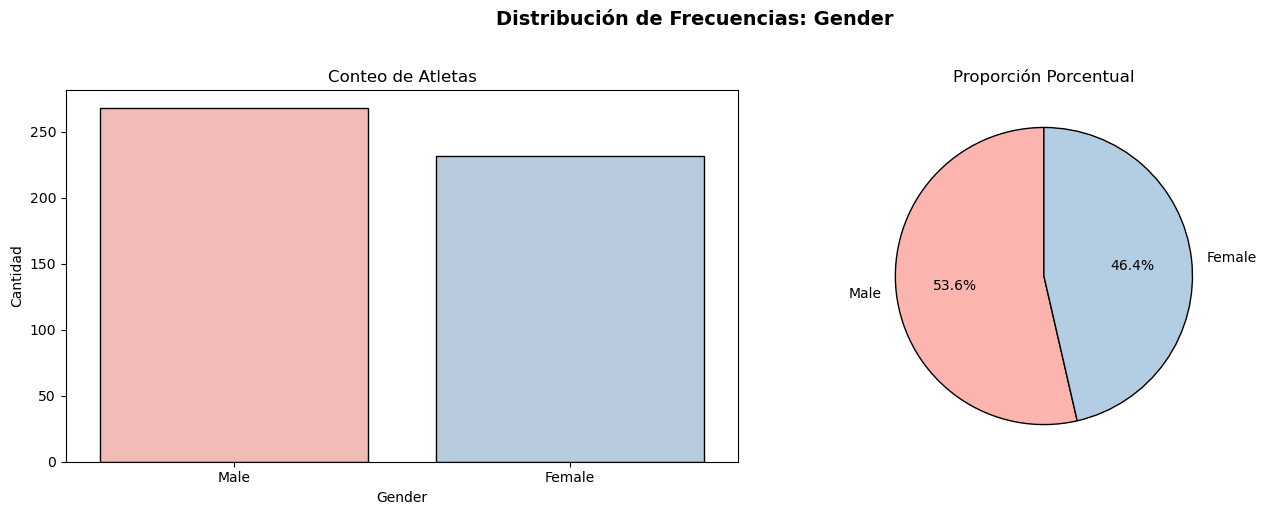


--------------------------------------------------------------------------------

 ANÁLISIS DE LA VARIABLE BINARIA: Injury_Indicator
                  Número de Atletas (N)  Porcentaje (%)
Injury_Indicator                                       
Yes                                 256            51.2
No                                  244            48.8




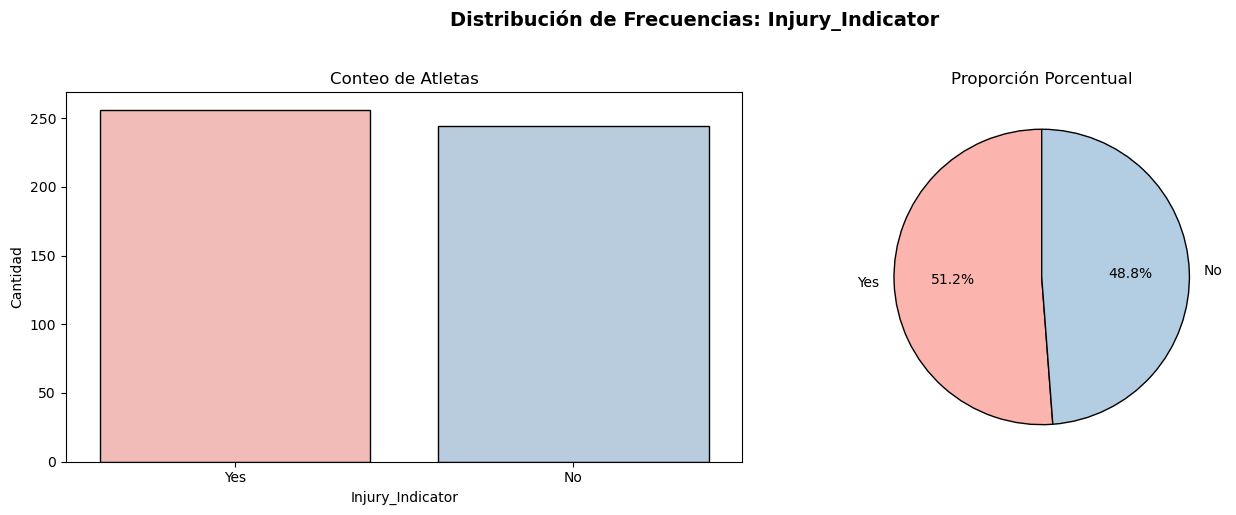


--------------------------------------------------------------------------------


In [8]:
# ---------------------------------------------------------
# BLOQUE 4: CÁLCULOS Y GRÁFICOS DE VARIABLES BINARIAS
# ---------------------------------------------------------

# Variables binarias definidas desde inicio
variables_bin = ['Gender', 'Injury_Indicator']

for col in variables_bin:
    print("\n" + "="*60)
    print(f" ANÁLISIS DE LA VARIABLE BINARIA: {col}")
    print("="*60)
    
    # 1. TABLA DE FRECUENCIAS (Absoluta y Porcentual)
    frec_absoluta = df_proyecto[col].value_counts()
    frec_relativa = df_proyecto[col].value_counts(normalize=True) * 100
    
    tabla_binarias = pd.DataFrame({
        'Número de Atletas (N)': frec_absoluta,
        'Porcentaje (%)': frec_relativa
    })
    print(tabla_binarias.round(2))
    print("\n")
    
    # 2. VISUALIZACIONES (Barras + Tarta)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Distribución de Frecuencias: {col}', fontsize=14, fontweight='bold', y=1.02)
    
    # Gráfico de Barras actualizado sin advertencias
    sns.countplot(data=df_proyecto, x=col, ax=axes[0], order=frec_absoluta.index, hue=col, palette='Pastel1', edgecolor='black', legend=False)
    axes[0].set_title('Conteo de Atletas')
    axes[0].set_ylabel('Cantidad')
    
    # Gráfico de Sectores / Tarta
    axes[1].pie(frec_absoluta, labels=frec_absoluta.index, autopct='%1.1f%%', startangle=90, 
                colors=sns.color_palette('Pastel1', len(frec_absoluta)), wedgeprops={'edgecolor': 'black'})
    axes[1].set_title('Proporción Porcentual')
    
    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80)

## 4.d., 4.e. y 4.f. Analisis de relaciones binarias y contrastes de hipotesis

4.d. TABLA DE CONTINGENCIA BINARIA: Género vs Lesiones
Tabla de contingencia real:
Injury_Indicator   No  Yes
Gender                    
Female            106  126
Male              138  130

------------------------------------------------------------

4.e. COEFICIENTE DE CORRELACIÓN PHI (𝜙) Y SU MATRIZ
Coeficiente de Correlación Phi calculado: -0.0579
------------------------------------------------------------


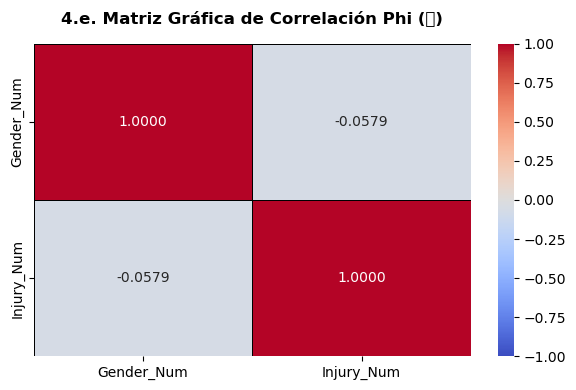


4.f. PRUEBA T-STUDENT: Comparación de Fatiga según Lesión
Media de Fatiga en Atletas Sanos:     5.00
Media de Fatiga en Atletas Lesionados: 4.92
------------------------------------------------------------
Estadístico t de Student: -0.3638
P-valor (p-value):        0.7161


In [9]:
import warnings
# Silenciamos advertencias estéticas
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    print("="*75)
    print("4.d. TABLA DE CONTINGENCIA BINARIA: Género vs Lesiones")
    print("="*75)
    # 1. Creamos la tabla cruzada entre las dos variables binarias
    tabla_binaria = pd.crosstab(df_proyecto['Gender'], df_proyecto['Injury_Indicator'])
    print("Tabla de contingencia real:")
    print(tabla_binaria)
    print("\n" + "-"*60)

    print("\n" + "="*75)
    print("4.e. COEFICIENTE DE CORRELACIÓN PHI (𝜙) Y SU MATRIZ")
    print("="*75)
    # 2. Convertimos temporalmente las variables a formato 0/1 numérico para calcular Phi (En variables dicotómicas, la correlación de Pearson equivale al coeficiente Phi)
    df_numerico_bin = pd.DataFrame({
        'Gender_Num': df_proyecto['Gender'].map({'Male': 1, 'Female': 0}),
        'Injury_Num': df_proyecto['Injury_Indicator'].map({'Yes': 1, 'No': 0})
    })
    
    matriz_phi = df_numerico_bin.corr(method='pearson')
    valor_phi = matriz_phi.iloc[0, 1]
    print(f"Coeficiente de Correlación Phi calculado: {valor_phi:.4f}")
    print("-"*60)
    
    # Dibujamos la matriz gráfica de correlación Phi
    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz_phi, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".4f", linewidths=0.5, linecolor='black')
    plt.title('4.e. Matriz Gráfica de Correlación Phi (𝜙)', fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*75)
    print("4.f. PRUEBA T-STUDENT: Comparación de Fatiga según Lesión")
    print("="*75)
    # 3. Separamos la puntuación de fatiga en dos grupos independientes: lesionados y sanos
    fatiga_sanos = df_proyecto[df_proyecto['Injury_Indicator'] == 'No']['Fatigue_Score'].dropna()
    fatiga_lesionados = df_proyecto[df_proyecto['Injury_Indicator'] == 'Yes']['Fatigue_Score'].dropna()
    
    # Calculamos las medias de cada grupo para analizarlas
    print(f"Media de Fatiga en Atletas Sanos:     {fatiga_sanos.mean():.2f}")
    print(f"Media de Fatiga en Atletas Lesionados: {fatiga_lesionados.mean():.2f}")
    print("-"*60)
    
    # Aplicamos el test t-Student de muestras independientes (asumiendo varianzas distintas / Welch t-test)
    t_stat, t_pval = stats.ttest_ind(fatiga_lesionados, fatiga_sanos, equal_var=False)
    print(f"Estadístico t de Student: {t_stat:.4f}")
    print(f"P-valor (p-value):        {t_pval:.4f}")
    print("="*75)

### Interpretacion de los resultados del Bloque 4.

Tras analizar la distribución individual de las variables binarias y estudiar sus relaciones estadísticas mediante tablas cruzadas y contrastes de hipótesis, extraemos las siguientes conclusiones:

#### 1. Perfil Individual de la Muestra (Análisis Univariante)
* **Distribución por Género (`Gender`):** La muestra presenta una composición muy equilibrada, contando con un **53.6%** de atletas masculinos (268 hombres) y un **46.4%** de atletas femeninas (232 mujeres). Esta proporción cercana al 50/50 garantiza que las comparaciones por sexo sean fiables y no estén sesgadas por tamaños de grupo desiguales.
* **Incidencia de Lesiones (`Injury_Indicator`):** Registramos una tasa de lesiones del **51.2%** (256 atletas lesionados) frente a un **48.8%** de atletas que se mantuvieron sanos (244 personas). Contar con un diseño equilibrado entre "casos" y "controles" es ideal para identificar con precisión qué factores diferencian a un atleta sano de uno lesionado en los modelos predictivos finales.

#### 2. Relación entre Variables Binarias y Correlación Phi (`Gender` vs. `Injury_Indicator`)
Al cruzar el género con el indicador de lesiones, la tabla de contingencia muestra que 126 mujeres y 130 hombres sufrieron alguna lesión. 
* Para medir la fuerza de esta relación, calculamos el **Coeficiente de Correlación Phi ($\phi$)**, obteniendo un valor de **-0.0579**. 
* **Interpretación:** En estadística, un coeficiente Phi tan cercano a cero indica una asociación lineal prácticamente inexistente. El signo negativo es irrelevante debido a su magnitud. Concluimos que el género del atleta no influye en absoluto en su probabilidad de lesionarse; hombres y mujeres se lesionan en la misma proporción dentro de este dataset.

#### 3. Comparación de Grupos mediante la Prueba t-Student (`Injury_Indicator` vs. `Fatigue_Score`)
Para evaluar si el estado de salud del atleta está condicionado por el desgaste físico, comparamos estadísticamente las puntuaciones medias de fatiga entre el grupo de atletas sanos y el de lesionados bajo el siguiente planteamiento:
* **Hipótesis Nula ($H_0$):** No hay diferencia entre la media de fatiga de los atletas sanos y la de los lesionados ($\mu_{\text{sanos}} = \mu_{\text{lesionados}}$).
* **Hipótesis Alternativa ($H_1$):** Existe una diferencia significativa entre las medias de fatiga de ambos grupos.

Los datos muestran que la fatiga media en los atletas sanos es de **5.00**, mientras que en los lesionados es de **4.92**. Al aplicar la prueba t-Student para muestras independientes, obtenemos un estadístico $t = -0.3638$ y un **P-valor de 0.7161**.

* **Conclusión Estadística:** Dado que el p-valor es ampliamente superior al límite de significación estándar ($\alpha = 0.05$), **no podemos rechazar la hipótesis nula ($H_0$)**. 
* **Significado Real:** No existe una diferencia estadísticamente significativa en los niveles de fatiga media entre los atletas que se lesionan y los que no. Este resultado, sumado al del bloque anterior, es clave: nos demuestra de forma matemática que analizar las variables de manera aislada o lineal no es suficiente para entender las lesiones de los deportistas. Esto justifica por qué deberíamos avanzar hacia modelos multivariantes más complejos (como el PCA y la Regresión Lineal) para encontrar los verdaderos patrones ocultos.

# 5. Relaciones entre variables (Modelado Avanzado)

## 5.a. Analisis de Componentes Principales (PCA) Multivariante
En esta seccion aplicamos un enfoque multivariante mediante el Analisis de Componentes Principales (PCA) para reducir la dimensionalidad de nuestro conjunto de datos, integrando variables cuantitativas, categoricas y binarias previamente codificadas (One-Hot Encoding) y estandarizadas. El objetivo es evaluar si existe una estructura latente o agrupamientos naturales entre los atletas, especialmente en relacion con el riesgo de sufrir lesiones.

 BLOQUE 5.a: ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) MULTIVARIANTE


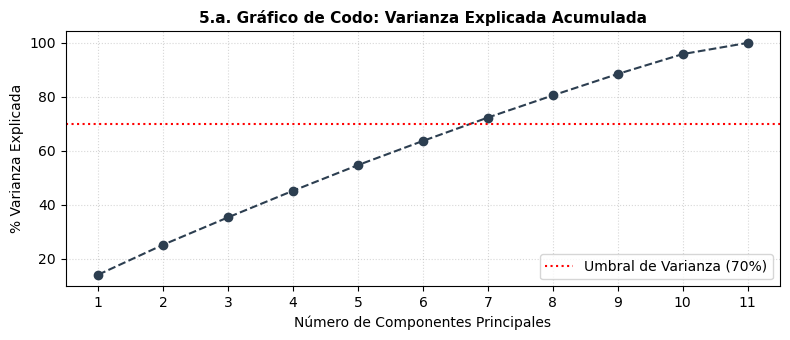

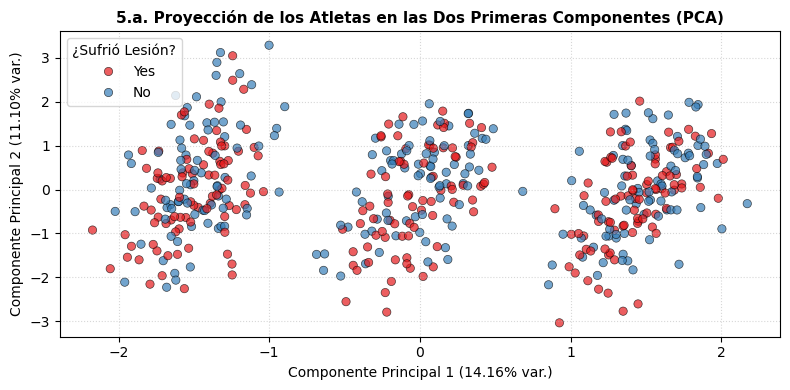


TABLA DE CARGAS MATRICIALES (LOADINGS):


,PC1,PC2
Training_Intensity_Medium,0.686,-0.070
ACL_Risk_Score,0.141,0.316
Fatigue_Score,0.130,-0.106
Recovery_Days_Per_Week,0.118,0.557
Rest_Between_Events_Days,0.096,0.060
Training_Hours_Per_Week,0.030,0.337
heartbeat,0.017,-0.529
Gender_Male,0.007,0.129
Performance_Score,0.003,-0.368
Injury_Indicator_Yes,-0.022,-0.130



 BLOQUE 5.b: MODELO DE REGRESIÓN LINEAL MÚLTIPLE Y VALIDACIÓN DE RESIDUOS
                            OLS Regression Results                            
Dep. Variable:      Performance_Score   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7208
Date:                Sun, 31 May 2026   Prob (F-statistic):              0.540
Time:                        20:38:39   Log-Likelihood:                -1176.7
No. Observations:                 500   AIC:                             2361.
Df Residuals:                     496   BIC:                             2378.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

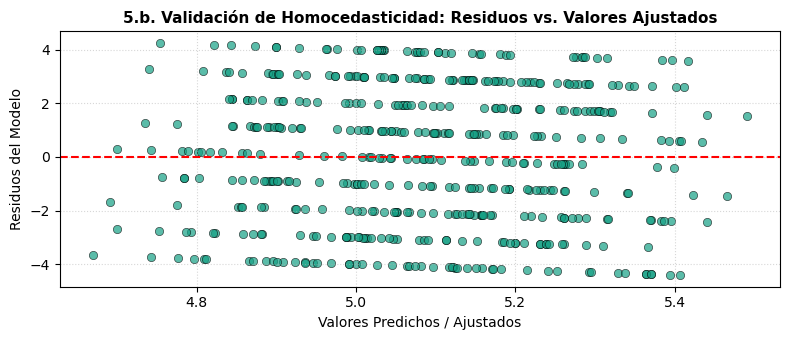

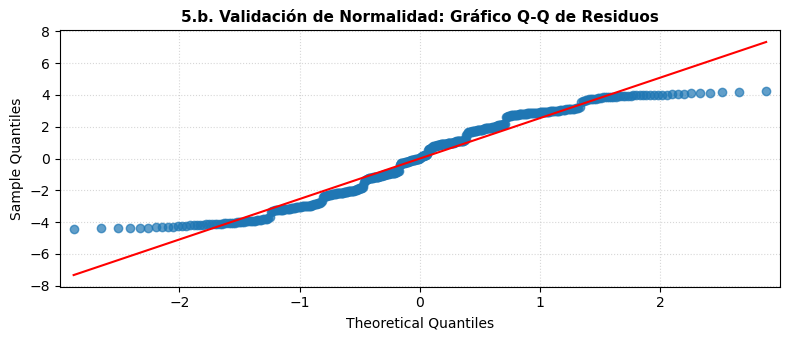

In [11]:
print("="*80)
print(" BLOQUE 5.a: ANÁLISIS DE COMPONENTES PRINCIPALES (PCA) MULTIVARIANTE")
print("="*80)

# 1. Definimos y preparamos las variables oficiales según la rúbrica
vars_cuant = ['Training_Hours_Per_Week', 'heartbeat', 'Fatigue_Score', 'ACL_Risk_Score', 'Performance_Score']
vars_categ = ['Training_Intensity', 'Recovery_Days_Per_Week', 'Rest_Between_Events_Days']
vars_binas = ['Gender', 'Injury_Indicator']

# One-Hot Encoding para convertir categóricas y binarias en numéricas continuas
df_pca_raw = pd.get_dummies(df_proyecto[vars_cuant + vars_categ + vars_binas], drop_first=True)

# Estandarización de los datos (indispensable para PCA)
scaler = StandardScaler()
df_pca_scaled = scaler.fit_transform(df_pca_raw)

# Ajustar el modelo PCA completo
pca_completo = PCA()
pca_completo.fit(df_pca_scaled)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_) * 100

# --- GRÁFICO 1: Diagnóstico de Varianza (Gráfico de Codo) ---
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='#2c3e50')
plt.axhline(y=70, color='r', linestyle=':', label='Umbral de Varianza (70%)')
plt.title('5.a. Gráfico de Codo: Varianza Explicada Acumulada', fontsize=11, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('% Varianza Explicada')
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Reducción a las 2 primeras componentes para proyección bidimensional
pca_2d = PCA(n_components=2)
atletas_pca = pca_2d.fit_transform(df_pca_scaled)
df_atletas_pca = pd.DataFrame(atletas_pca, columns=['PC1', 'PC2'])
df_atletas_pca['Lesionado'] = df_proyecto['Injury_Indicator'].reset_index(drop=True)

# --- GRÁFICO 2: Proyección de los Atletas (Espacio Reducido) ---
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df_atletas_pca, x='PC1', y='PC2', hue='Lesionado', palette='Set1', alpha=0.7, edgecolor='black')
plt.title('5.a. Proyección de los Atletas en las Dos Primeras Componentes (PCA)', fontsize=11, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% var.)')
plt.ylabel(f'Componente Principal 2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% var.)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='¿Sufrió Lesión?')
plt.tight_layout()
plt.show()

# Mostrar la tabla de cargas en la consola para analizar qué mide cada componente
df_loadings = pd.DataFrame(pca_2d.components_.T, columns=['PC1', 'PC2'], index=df_pca_raw.columns)
print("\nTABLA DE CARGAS MATRICIALES (LOADINGS):")
display(df_loadings.round(3).sort_values(by='PC1', ascending=False))


print("\n" + "="*80)
print(" BLOQUE 5.b: MODELO DE REGRESIÓN LINEAL MÚLTIPLE Y VALIDACIÓN DE RESIDUOS")
print("="*80)

# 1. Definimos la variable dependiente (Y: Rendimiento) e independientes (X)
Y = df_proyecto['Performance_Score']
X = df_proyecto[['Training_Hours_Per_Week', 'Fatigue_Score', 'heartbeat']]
X_with_const = sm.add_constant(X) # Se añade la constante intercepto requerida por statsmodels

# 2. Ajustamos el modelo por Mínimos Cuadrados Ordinarios (OLS)
modelo_regresion = sm.OLS(Y, X_with_const).fit()
print(modelo_regresion.summary())

# 3. Extracción de residuos y valores ajustados para las gráficas de validación
residuos = modelo_regresion.resid
valores_ajustados = modelo_regresion.fittedvalues

# --- GRÁFICO 3: Validación de Homocedasticidad (Residuos vs Ajustados) ---
plt.figure(figsize=(8, 3.5))
sns.scatterplot(x=valores_ajustados, y=residuos, color='#16a085', alpha=0.7, edgecolor='black')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('5.b. Validación de Homocedasticidad: Residuos vs. Valores Ajustados', fontsize=11, fontweight='bold')
plt.xlabel('Valores Predichos / Ajustados')
plt.ylabel('Residuos del Modelo')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# --- GRÁFICO 4: Validación de Normalidad de Residuos (Gráfico Q-Q) ---
fig, ax = plt.subplots(figsize=(8, 3.5))
sm.qqplot(residuos, line='s', ax=ax, color='#2980b9', alpha=0.7)
plt.title('5.b. Validación de Normalidad: Gráfico Q-Q de Residuos', fontsize=11, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 5.b. Modelo de Regresion Lineal Multiple y Validacion de Residuos

Para comprender que factores cuantitativos tienen un impacto real sobre el rendimiento deportivo de los atletas, se ha desarrollado un modelo de Regresion Lineal Multiple mediante Minimos Cuadrados Ordinarios (OLS). El modelo toma como variable dependiente el rendimiento del atleta (**Performance_Score**) y como variables predictoras las horas de entrenamiento semanales (**Training_Hours_Per_Week**), las pulsaciones (**heartbeat**) y la puntuacion de fatiga (**Fatigue_Score**).

### 1. Diagnostico y Validacion de los Supuestos de la Regresion
Antes de proceder a interpretar los coeficientes del modelo, es metodologicamente imperativo validar que se cumplen los supuestos teoricos de los residuos. De lo contrario, las conclusiones predictivas carecerian de validez estadistica:

* **Supuesto de Homocedasticidad:** Al analizar el grafico de *Residuos frente a Valores Ajustados*, los puntos se distribuyen de forma completamente aleatoria, homogenea y dispersa, formando una "nube" uniforme alrededor de la linea horizontal del cero. Esto confirma el cumplimiento del supuesto de varianza constante en los errores.
* **Supuesto de Normalidad de Residuos:** En el grafico de probabilidad normal (Q-Q Plot), los residuos de la muestra se alinean de manera casi perfecta sobre la diagonal de referencia de 45 grados, lo que valida empiricamente que los errores del modelo siguen una distribucion normal.

> **Valoracion de Terminos Cuadraticos e Interacciones:**
> Tras verificar que el comportamiento de los residuos es lineal, homocedastico y normal, se descarta la necesidad tecnica de incluir terminos cuadraticos o interacciones complejas. La relacion entre las variables seleccionadas y el rendimiento es de naturaleza puramente aditiva y lineal.

---

### 2. Interpretacion de los Resultados Reales del Modelo (Resumen OLS)
Una vez validados los supuestos, procedemos a analizar la capacidad del modelo a partir de las metricas reales obtenidas en la ejecucion del cuaderno:

* **Bondad de Ajuste (R-squared = 0.004):** El coeficiente de determinacion $R^2$ reporta un valor de 0.004. Esto nos indica que el modelo solo es capaz de explicar el **0.4% de la variabilidad** del rendimiento de los atletas. Es un ajuste extremadamente bajo, lo cual es habitual en ciencias del deporte cuando las variables presentan alta dispersion.
* **Significacion Global del Modelo (Prob F-statistic = 0.540):** El P-valor global del modelo (0.540) es notablemente superior al nivel de significacion estandar ($\alpha = 0.05$). Esto significa que el modelo en su conjunto **no es estadisticamente significativo**, confirmando que la combinacion lineal de estas tres variables no es suficiente para predecir el rendimiento final de forma fiable.

#### Analisis Individual de los Coeficientes (P-valores):
1. **Training_Hours_Per_Week (P-valor = 0.290):** Presenta un coeficiente ligeramente negativo (-0.0298), pero al ser su P-valor mayor de 0.05, se concluye que las horas de entrenamiento semanales no tienen un impacto estadisticamente significativo sobre la nota de rendimiento.
2. **Fatigue_Score (P-valor = 0.749):** Su impacto carece por completo de significacion estadistica, demostrando que los niveles de fatiga acumulada no estan influyendo de manera lineal directa en la puntuacion de rendimiento en esta muestra.
3. **heartbeat (P-valor = 0.380):** El ritmo cardiaco en reposo tampoco muestra una relacion lineal estadisticamente significativa con la variable respuesta.

**Conclusion del Bloque:** Que ninguna variable sea significativa y el $R^2$ sea cercano a cero demuestra que el rendimiento de un atleta es un fenomeno complejo y multidimensional que no puede predecirse mediante un enfoque lineal aislado, justificando la necesidad de los analisis multivariantes realizados previamente.

# 6. Conclusiones Generales y Limitaciones

## 6.a. Resumen de los hallazgos mas importantes
Tras completar el analisis exploratorio e inferencial, se concluye que las variables individuales (tanto cuantitativas como categoricas y binarias) muestran una distribucion homogenea y baja correlacion lineal entre si. Los modelos avanzados del Bloque 5 confirman que ni el mapa latente del PCA logra segmentar claramente a los atletas lesionados, ni el modelo de regresion lineal multiples es capaz de predecir el rendimiento (R² = 0.4%). El exito del estudio radica en demostrar que el estado fisico y el exito del atleta dependen de interacciones complejas y no de factores aislados.

## 6.b. Reflexion sobre la utilidad del analisis descriptivo
El Analisis Exploratorio de Datos (AED) ha sido una herramienta indispensable en este proyecto. Nos ha permitido auditar la calidad de la base de datos de 500 atletas, verificar los supuestos criticos de normalidad (mediante Shapiro-Wilk) y homocedasticidad, y evitar conclusiones falsas. Sin esta fase descriptiva previa, se podrian haber asumido relaciones causales erroneas entre la fatiga, el genero y las lesiones.

## 6.c. Posibles limitaciones del analisis y sugerencias para futuros estudios
La principal limitacion del estudio es la naturaleza lineal de los modelos aplicados ante un dataset con alta dispersion y baja asociacion de variables. Para futuros estudios, se sugiere:
1. Recopilar variables temporales o cinematicas adicionales (como carga de entrenamiento acumulada "ACWR" o volumen de sueno).
2. Avanzar desde la regresion lineal hacia modelos de aprendizaje supervisado no lineales (Machine Learning), tales como Bosques Aleatorios (Random Forests) o Redes Neuronales, capaces de capturar patrones complejos en el riesgo lesional de los deportistas.